## Marketing Campaigns

## Problem scenario:
Marketing mix stands as a widely utilized concept in the execution of marketing strategies. It encompasses various facets within a comprehensive marketing plan, with a central focus on the four Ps of marketing: product, price, place, and promotion.
#### Problem objective:

As a data scientist, you must conduct exploratory data analysis and hypothesis testing to enhance your comprehension of the diverse factors influencing customer acquisition.

#### Data description:

The dataset aligns with the Four Ps of Marketing, categorizing variables to analyze consumer behavior. Product-related variables track spending across categories, while Price factors like income and deal-based purchases indicate affordability. Place covers shopping channels and web visits, reflecting purchase preferences. Promotion measures campaign engagement, complaints, and recency. Additionally, demographics support segmentation for personalized marketing. This structured approach helps businesses optimize products, pricing, distribution, and promotions for better customer engagement and market performance.

#### Steps to perform:

- After importing the data, examine variables such as Dt_Customer and Income to verify their accurate importation.
- There are missing income values for some customers. Conduct missing value imputation, considering that customers with similar education and marital status tend to have comparable yearly incomes, on average. It may be necessary to cleanse the data before proceeding. Specifically, scrutinize the categories of education and marital status for data cleaning. 
- Create variables to represent the total number of children, age, and total spending.
- Derive the total purchases from the number of transactions across the three channels.
- Generate box plots and histograms to gain insights into the distributions and identify outliers. Implement outlier treatment as needed.
- Apply ordinal and one-hot encoding based on the various types of categorical variables.
- Generate a heatmap to illustrate the correlation between different pairs of variables.
#### Test the following hypotheses:
- Older individuals may not possess the same level of technological proficiency and may, therefore, lean toward traditional in-store shopping preferences.
- Customers with children likely experience time constraints, making online shopping a more convenient option.
- Sales at physical stores may face the risk of cannibalization by alternative distribution channels.
- Does the United States significantly outperform the rest of the world in total purchase volumes?
#### Use appropriate visualization to help analyze the following:
- Identify the top-performing products and those with the lowest revenue.
- Examine if there is a correlation between customers' age and the acceptance rate of the last campaign.
- Determine the country with the highest number of customers who accepted the last campaign.
- Investigate if there is a discernible pattern in the number of children at home and the total expenditure.
- Analyze the educational background of customers who lodged complaints in the last two years.

In [19]:
# Data analysis 
import pandas as pd
import numpy as np

df = pd.read_csv('marketing_data.csv')
# Display the first few rows of the dataset
print(df.head())
# Check for missing values
print(df.isnull().sum())

      ID  Year_Birth   Education Marital_Status      Income   Kidhome  \
0   1826        1970  Graduation       Divorced  $84,835.00         0   
1      1        1961  Graduation         Single  $57,091.00         0   
2  10476        1958  Graduation        Married  $67,267.00         0   
3   1386        1967  Graduation       Together  $32,474.00         1   
4   5371        1989  Graduation         Single  $21,474.00         1   

   Teenhome Dt_Customer  Recency  MntWines  ...  NumStorePurchases  \
0         0     6/16/14        0       189  ...                  6   
1         0     6/15/14        0       464  ...                  7   
2         1     5/13/14        0       134  ...                  5   
3         1     5/11/14        0        10  ...                  2   
4         0      4/8/14        0         6  ...                  2   

   NumWebVisitsMonth  AcceptedCmp3  AcceptedCmp4  AcceptedCmp5  AcceptedCmp1  \
0                  1             0             0            

In [20]:
# Conduct missing value imputation, considering that customers with similar education and marital status tend to have comparable yearly incomes, on average. It may be necessary to cleanse the data before proceeding.

# Clean the 'Income' column by removing '$' and ',' and converting to float
df.columns = df.columns.str.strip()
df['Income'] = df['Income'].astype(str).str.replace(r'[\$,]', '', regex=True).str.strip()
df['Income'] = pd.to_numeric(df['Income'], errors='coerce')

# Impute missing values in the 'Income' column based on the average income of customers with similar education and marital status
# Group the data by 'Education' and 'Marital_Status' and calculate the mean income for each group
#income_means = df.groupby(['Education', 'Marital_Status'])['Income'].mean()

# Fill missing values with the group mean
df['Income'] = df.groupby(['Education', 'Marital_Status'])['Income'].transform(lambda x: x.fillna(x.mean()))

print(df['Income'].isnull().sum())  # Verify no missing values remain

0


In [21]:
print(df.head())
print(df.tail())


      ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0   1826        1970  Graduation       Divorced  84835.0        0         0   
1      1        1961  Graduation         Single  57091.0        0         0   
2  10476        1958  Graduation        Married  67267.0        0         1   
3   1386        1967  Graduation       Together  32474.0        1         1   
4   5371        1989  Graduation         Single  21474.0        1         0   

  Dt_Customer  Recency  MntWines  ...  NumStorePurchases  NumWebVisitsMonth  \
0     6/16/14        0       189  ...                  6                  1   
1     6/15/14        0       464  ...                  7                  5   
2     5/13/14        0       134  ...                  5                  2   
3     5/11/14        0        10  ...                  2                  7   
4      4/8/14        0         6  ...                  2                  7   

   AcceptedCmp3  AcceptedCmp4  AcceptedCmp5  Accep

In [22]:
#Analyze the categories of education and marital status for data cleaning. 
print(df['Education'].value_counts())
print(df['Marital_Status'].value_counts())  

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64
Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
YOLO          2
Absurd        2
Name: count, dtype: int64


In [24]:
# Create variables to represent the total number of children, age, and total spending.
# Create a new column 'Total_Children' by summing 'Kidhome' and 'Teenhome'
df['Total_Children'] = df['Kidhome'] + df['Teenhome']
# Create a new column 'Total_Spending' by summing the spending columns
spending_columns = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
df['Total_Spending'] = df[spending_columns].sum(axis=1)

In [25]:
print(df.head())

      ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0   1826        1970  Graduation       Divorced  84835.0        0         0   
1      1        1961  Graduation         Single  57091.0        0         0   
2  10476        1958  Graduation        Married  67267.0        0         1   
3   1386        1967  Graduation       Together  32474.0        1         1   
4   5371        1989  Graduation         Single  21474.0        1         0   

  Dt_Customer  Recency  MntWines  ...  AcceptedCmp3  AcceptedCmp4  \
0     6/16/14        0       189  ...             0             0   
1     6/15/14        0       464  ...             0             0   
2     5/13/14        0       134  ...             0             0   
3     5/11/14        0        10  ...             0             0   
4      4/8/14        0         6  ...             1             0   

   AcceptedCmp5  AcceptedCmp1  AcceptedCmp2  Response  Complain  Country  \
0             0             0     

In [26]:
#Derive the total purchases from the number of transactions across the three channels.
df['Total_Purchases'] = df['NumWebPurchases'] + df['NumCatalogPurchases'] + df['NumStorePurchases']
print(df.head())

      ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0   1826        1970  Graduation       Divorced  84835.0        0         0   
1      1        1961  Graduation         Single  57091.0        0         0   
2  10476        1958  Graduation        Married  67267.0        0         1   
3   1386        1967  Graduation       Together  32474.0        1         1   
4   5371        1989  Graduation         Single  21474.0        1         0   

  Dt_Customer  Recency  MntWines  ...  AcceptedCmp4  AcceptedCmp5  \
0     6/16/14        0       189  ...             0             0   
1     6/15/14        0       464  ...             0             0   
2     5/13/14        0       134  ...             0             0   
3     5/11/14        0        10  ...             0             0   
4      4/8/14        0         6  ...             0             0   

   AcceptedCmp1  AcceptedCmp2  Response  Complain  Country  Total_Children  \
0             0             0   

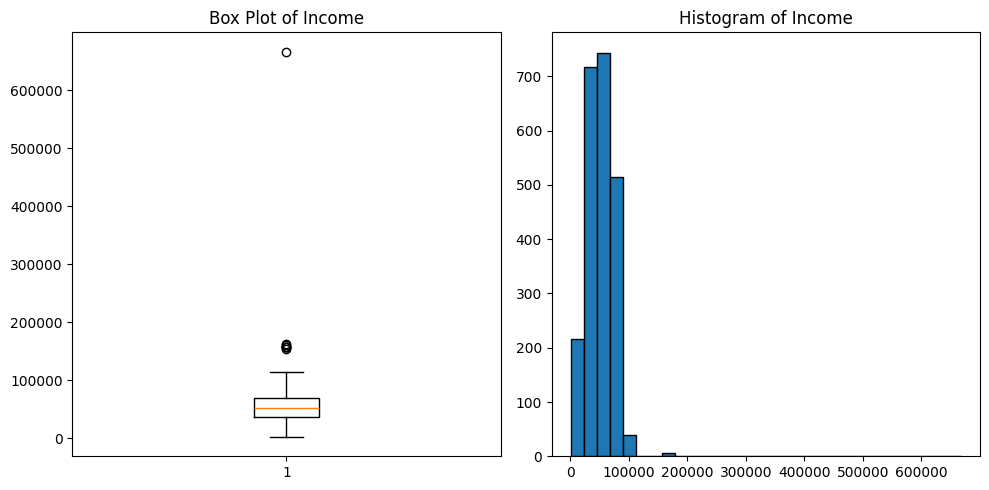

In [27]:
# Generate box plots and histograms to gain insights into the distributions and identify outliers. Implement outlier treatment as needed
import matplotlib.pyplot as plt
# Box plot for 'Income'
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.boxplot(df['Income'].dropna())
plt.title('Box Plot of Income')
# Histogram for 'Income'
plt.subplot(1, 2, 2)
plt.hist(df['Income'].dropna(), bins=30, edgecolor='k')
plt.title('Histogram of Income')
plt.tight_layout()
plt.show()  

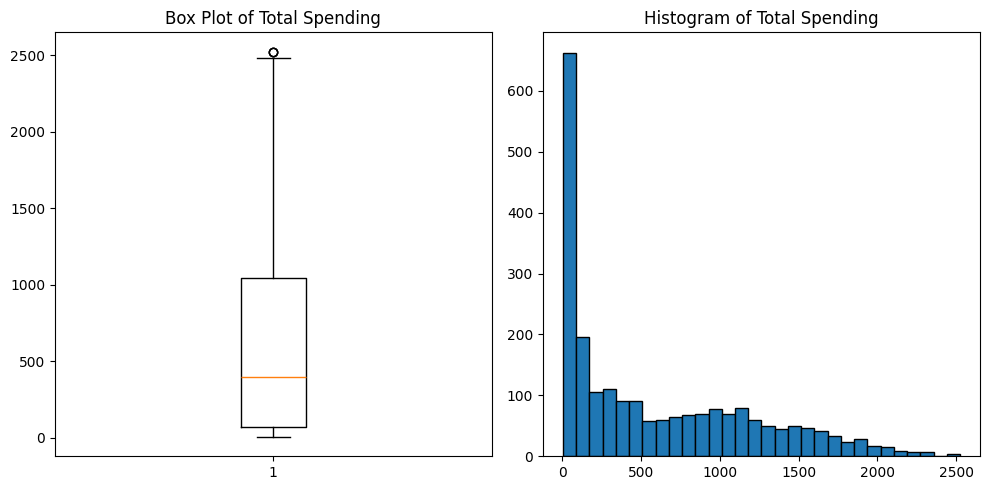

In [28]:
# Box plot for 'Total_Spending'
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.boxplot(df['Total_Spending'].dropna())
plt.title('Box Plot of Total Spending')
# Histogram for 'Total_Spending'
plt.subplot(1, 2, 2)
plt.hist(df['Total_Spending'].dropna(), bins=30, edgecolor='k')
plt.title('Histogram of Total Spending')
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Box Plot of Total Purchases')

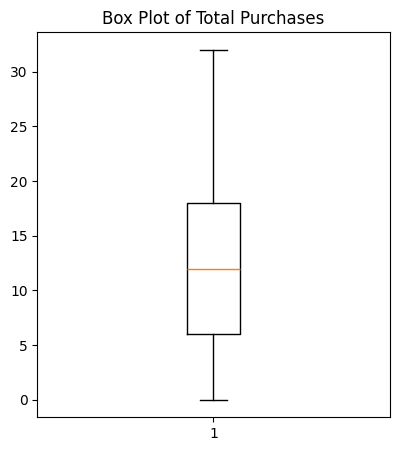

In [29]:
# box plot for 'Total_Purchases'
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.boxplot(df['Total_Purchases'].dropna())
plt.title('Box Plot of Total Purchases')

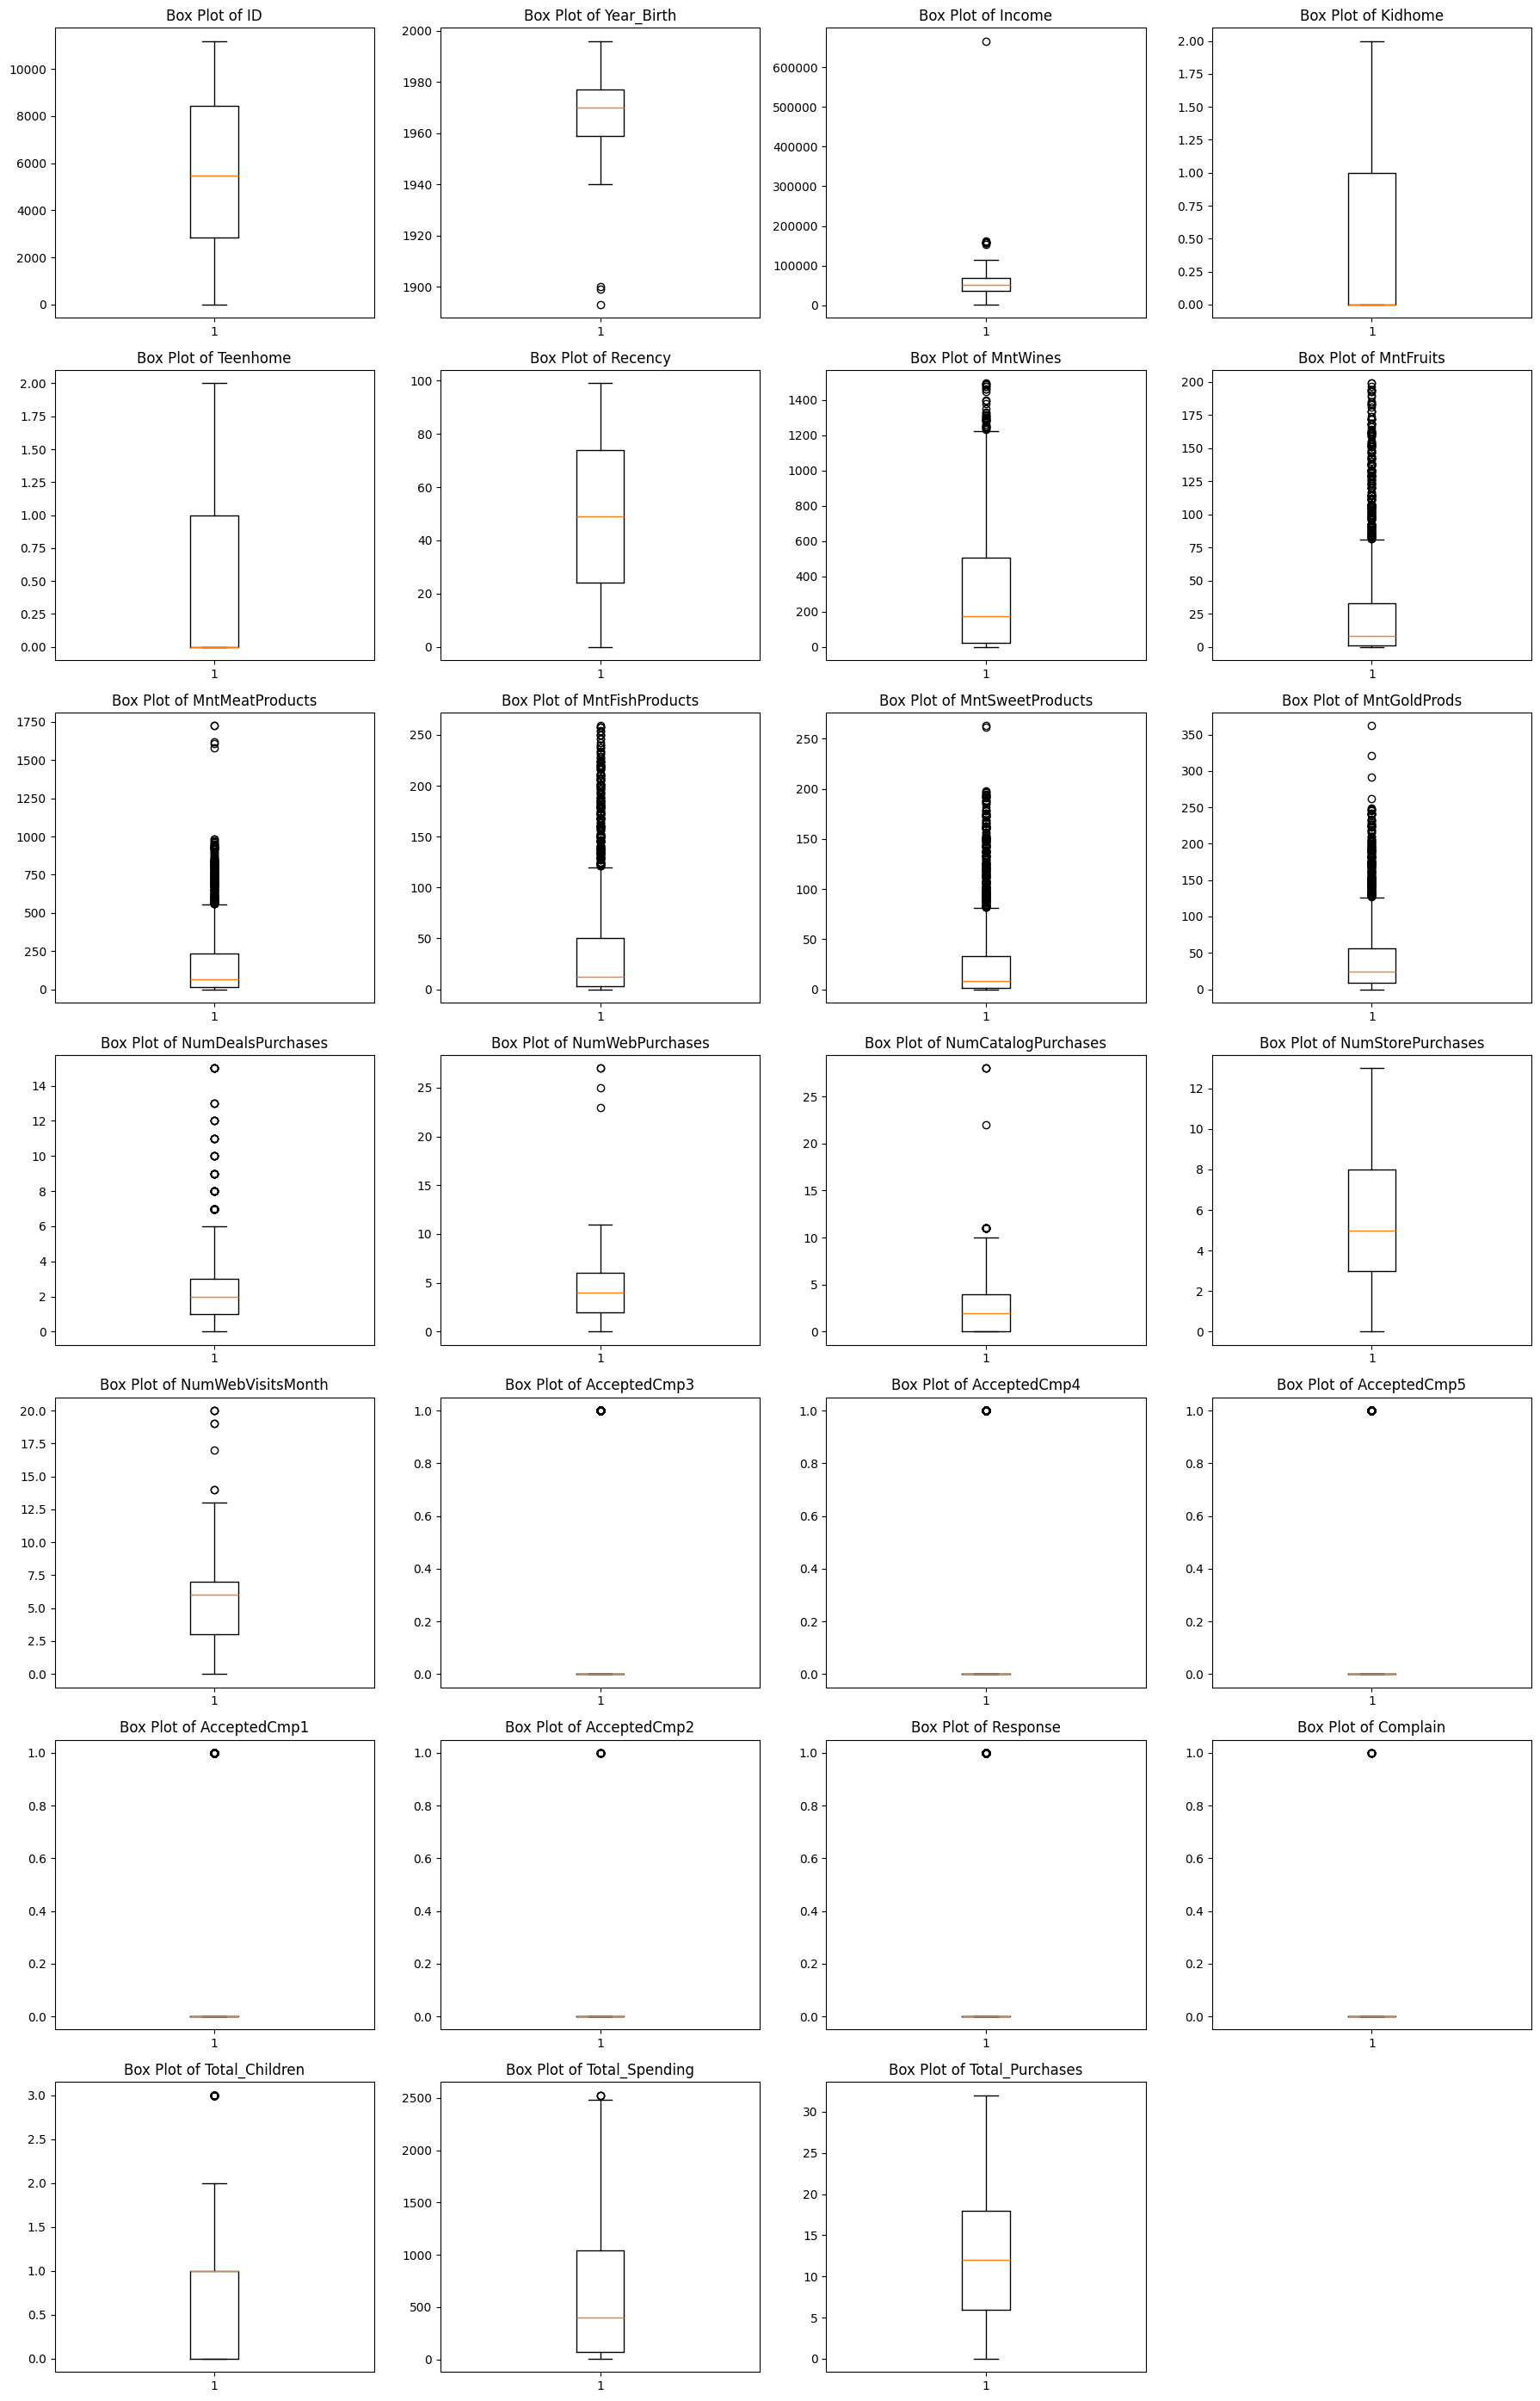

In [32]:
# box plot for all numeric columns
numeric_columns = df.select_dtypes(include=[np.number]).columns
n_cols = 4
n_rows = int(np.ceil(len(numeric_columns) / n_cols))

plt.figure(figsize=(18, 4 * n_rows))
for i, column in enumerate(numeric_columns):
    plt.subplot(n_rows, n_cols, i + 1)
    plt.boxplot(df[column].dropna())
    plt.title(f'Box Plot of {column}')
plt.tight_layout()
plt.show()

## Observations 
- Products which has most outliers : Fruits, Fish products, Meat products, Sweet products , Gold products  

In [51]:
# Identify categorical columns
categorical_columns = df.select_dtypes(include=['object']).columns
print("Categorical columns:", categorical_columns)
# identify string columns
string_columns = df.select_dtypes(include=['string']).columns
print("String columns:", string_columns)

#Apply ordinal and one-hot encoding based on the various types of categorical columns.
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
# One-hot encode the 'Education' column
one_hot_encoder = OneHotEncoder(sparse_output=False, drop='first')
education_encoded = one_hot_encoder.fit_transform(df[['Education']])
education_encoded_df = pd.DataFrame(education_encoded, columns=one_hot_encoder.get_feature_names_out(['Education']))
df = pd.concat([df, education_encoded_df], axis=1)
# Ordinal encode the 'Marital_Status' column
ordinal_encoder = OrdinalEncoder()
df['Marital_Status_Encoded'] = ordinal_encoder.fit_transform(df[['Marital_Status']])
# Ordinal encode the 'Dt_Customer' column
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], errors='coerce')
df['Dt_Customer_Encoded'] = df['Dt_Customer'].map(lambda x: x.toordinal() if pd.notnull(x) else np.nan)

# Ordinal encode the 'Country' column
ordinal_encoder = OrdinalEncoder()
df['Country_Encoded'] = ordinal_encoder.fit_transform(df[['Country']])
# Ordinal encode the 'Education' column
ordinal_encoder = OrdinalEncoder()
df['Education_Encoded'] = ordinal_encoder.fit_transform(df[['Education']])  
# Ordinal encode the 'Marital_Status' column
ordinal_encoder = OrdinalEncoder()
df['Marital_Status_Encoded'] = ordinal_encoder.fit_transform(df[['Marital_Status']])


print(df.head())        

Categorical columns: Index(['Education', 'Marital_Status', 'Country'], dtype='str')
String columns: Index(['Education', 'Marital_Status', 'Country'], dtype='str')
      ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0   1826        1970  Graduation       Divorced  84835.0        0         0   
1      1        1961  Graduation         Single  57091.0        0         0   
2  10476        1958  Graduation        Married  67267.0        0         1   
3   1386        1967  Graduation       Together  32474.0        1         1   
4   5371        1989  Graduation         Single  21474.0        1         0   

  Dt_Customer  Recency  MntWines  ...  Education_Graduation  Education_Master  \
0  2014-06-16        0       189  ...                   1.0               0.0   
1  2014-06-15        0       464  ...                   1.0               0.0   
2  2014-05-13        0       134  ...                   1.0               0.0   
3  2014-05-11        0        10  ... 

/var/folders/ny/plc47xp50r72ppfcjmyv55hc0000gp/T/ipykernel_28457/1700581183.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=['object']).columns


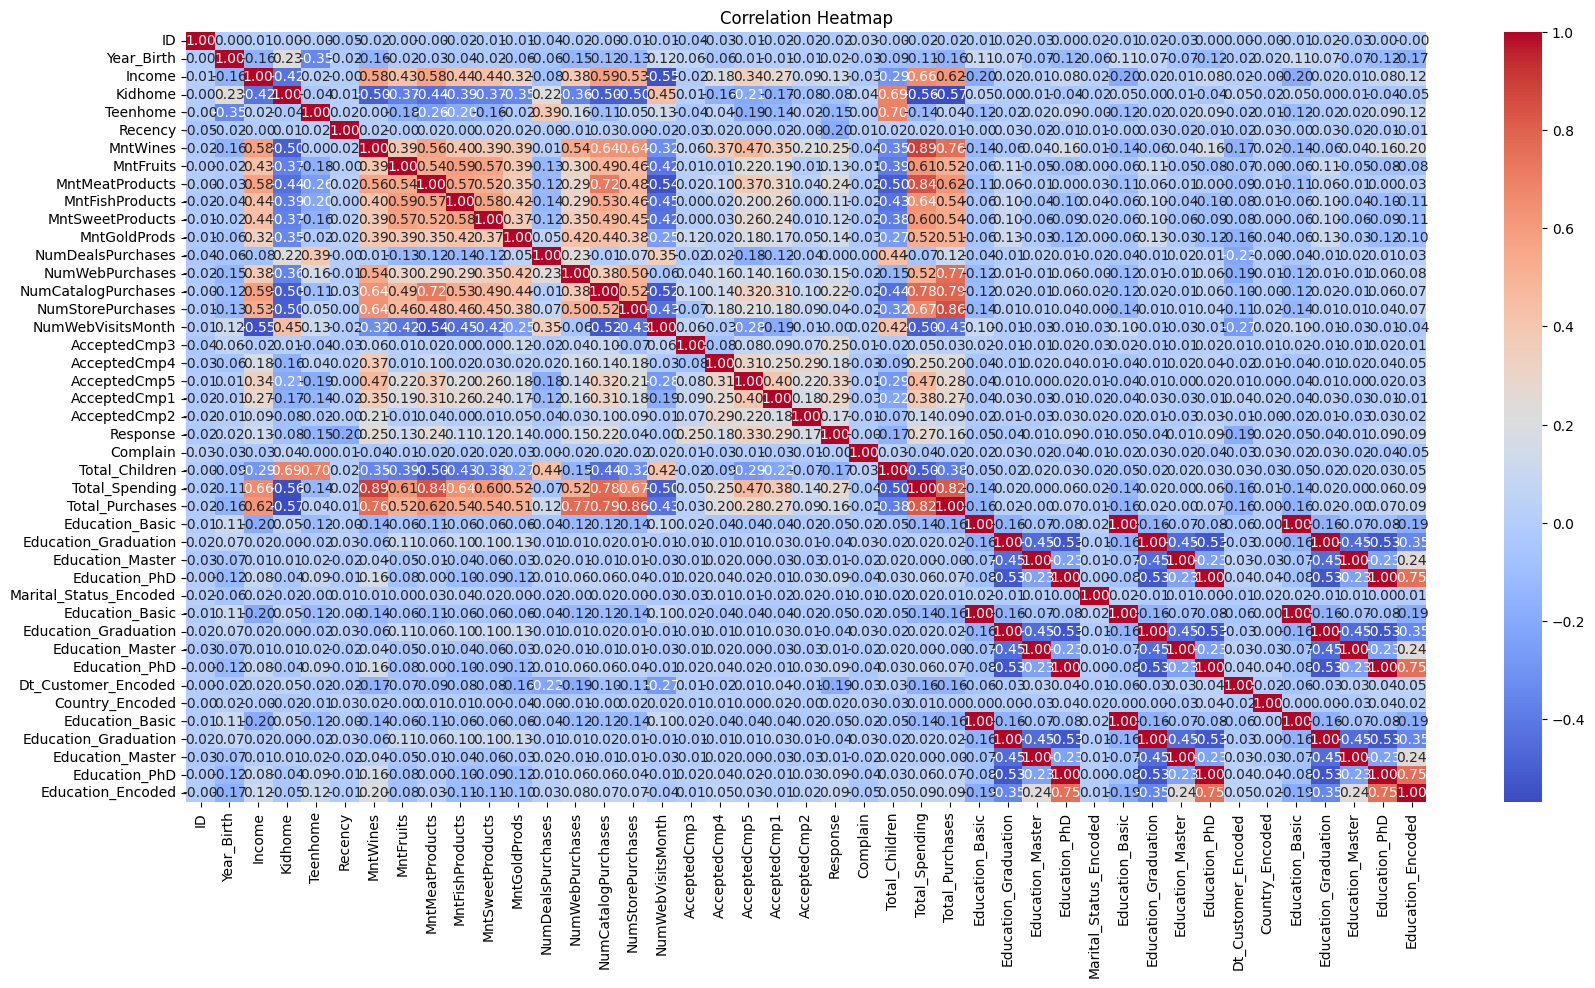

In [57]:
# Generate a heatmap to illustrate the correlation between different pairs of variables.

import seaborn as sns
correlation_matrix = df.select_dtypes(include=[np.number]).corr()
plt.figure(figsize=(20, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

#### Hypotheses Testing:
- Older individuals may not possess the same level of technological proficiency and may, therefore, lean toward traditional in-store shopping preferences.
- Customers with children likely experience time constraints, making online shopping a more convenient option.
- Sales at physical stores may face the risk of cannibalization by alternative distribution channels.
- Does the United States significantly outperform the rest of the world in total purchase volumes?

In [68]:
# Hypotheses testing : Older individuals may not possess the same level of technological proficiency and may, therefore, lean toward traditional in-store shopping preferences.
# seperate the data into two groups based on age
older_group = df[df['Year_Birth'] <= 1974]  # Assuming the current year is 2024, 50 years old or older
younger_group = df[df['Year_Birth'] > 1974]
# Calculate the average number of store purchases for each group
older_store_purchases = older_group['NumStorePurchases'].mean()
younger_store_purchases = younger_group['NumStorePurchases'].mean()
print(f'Average number of store purchases for older individuals: {older_store_purchases:.2f}')
print(f'Average number of store purchases for younger individuals: {younger_store_purchases:.2f}')

# calculate the average number of web purchases for each group
older_web_purchases = older_group['NumWebPurchases'].mean()
younger_web_purchases = younger_group['NumWebPurchases'].mean()
print(f'Average number of web purchases for older individuals: {older_web_purchases:.2f}')
print(f'Average number of web purchases for younger individuals: {younger_web_purchases:.2f}')

# Perform the independent two-sample t-test 
from scipy.stats import ttest_ind
t_statistic, p_value = ttest_ind(older_group['NumStorePurchases'].dropna(), younger_group['NumStorePurchases'].dropna(), equal_var=False)
#t_statistic, p_value = ttest_ind(older_group['NumWebPurchases'].dropna(), younger_group['NumWebPurchases'].dropna(), equal_var=False)
print(f'T-statistic: {t_statistic:.2f}, P-value: {p_value:.4f}')

#interpret the results
alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis: There is a significant difference in store purchases between older and younger individuals.")
else:    print("Fail to reject the null hypothesis: There is no significant difference in store purchases between older and younger individuals.")
      

Average number of store purchases for older individuals: 6.01
Average number of store purchases for younger individuals: 5.37
Average number of web purchases for older individuals: 4.33
Average number of web purchases for younger individuals: 3.63
T-statistic: 4.49, P-value: 0.0000
Reject the null hypothesis: There is a significant difference in store purchases between older and younger individuals.


In [70]:
# Hypothesis testing: Customers with children likely experience time constraints, making online shopping a more convenient option.
# Create a new column 'Has_Children' to indicate whether a customer has children
df['Has_Children'] = df['Total_Children'] > 0
# Calculate the average number of web purchases for customers with and without children
with_children_web_purchases = df[df['Has_Children']]['NumWebPurchases'].mean()
without_children_web_purchases = df[~df['Has_Children']]['NumWebPurchases'].mean()
print(f'Average number of web purchases for customers with children: {with_children_web_purchases:.2f}')
print(f'Average number of web purchases for customers without children: {without_children_web_purchases:.2f}')
# Perform the independent two-sample t-test
t_statistic, p_value = ttest_ind(df[df['Has_Children']]['NumWebPurchases'].dropna(), df[~df['Has_Children']]['NumWebPurchases'].dropna(), equal_var=False)
print(f'T-statistic: {t_statistic:.2f}, P-value: {p_value:.4f}')
# Interpret the results
if p_value < alpha:
    print("Reject the null hypothesis: There is a significant difference in web purchases between customers with and without children.")
else:    print("Fail to reject the null hypothesis: There is no significant difference in web purchases between customers with and without children.")  

Average number of web purchases for customers with children: 3.96
Average number of web purchases for customers without children: 4.39
T-statistic: -3.54, P-value: 0.0004
Reject the null hypothesis: There is a significant difference in web purchases between customers with and without children.


In [78]:
# Sales at physical stores may face the risk of cannibalization by alternative distribution channels like NumDealsPurchases and NumcatalogPurchases, which may offer more competitive pricing and convenience.
# Hypothesis testing: Customers who make online purchases may reduce their in-store purchases.
# Calculate the average number of store purchases for customers who make online purchases and those who do not
from scipy.stats import f_oneway


online_purchasers_store_purchases = df[df['NumWebPurchases'] > 0]['NumStorePurchases'].mean()
non_online_purchasers_store_purchases = df[df['NumWebPurchases'] == 0]['NumStorePurchases'].mean()
deal_purchasers_store_purchases = df[df['NumDealsPurchases'] > 0]['NumStorePurchases'].mean()
catalog_purchasers_store_purchases = df[df['NumCatalogPurchases'] > 0]['NumStorePurchases'].mean()
print(f'Average number of store purchases for online purchasers: {online_purchasers_store_purchases:.2f}')
print(f'Average number of store purchases for non-online purchasers: {non_online_purchasers_store_purchases:.2f}')
print(f'Average number of store purchases for deal purchasers: {deal_purchasers_store_purchases:.2f}')
print(f'Average number of store purchases for catalog purchasers: {catalog_purchasers_store_purchases:.2f}')
# Perform one-way ANOVA across the four groups
f_statistic, p_value = f_oneway(
    df.loc[df['NumWebPurchases'] > 0, 'NumStorePurchases'].dropna().to_numpy(),
    df.loc[df['NumWebPurchases'] == 0, 'NumStorePurchases'].dropna().to_numpy(),
    df.loc[df['NumDealsPurchases'] > 0, 'NumStorePurchases'].dropna().to_numpy(),
    df.loc[df['NumCatalogPurchases'] > 0, 'NumStorePurchases'].dropna().to_numpy()
)
print(f'F-statistic: {f_statistic:.2f}, P-value: {p_value:.4f}')
# Interpret the results
if p_value < alpha:
    print("Reject the null hypothesis: There is a significant difference in store purchases among online purchasers, non-online purchasers, deal purchasers, and catalog purchasers.")
else:    print("Fail to reject the null hypothesis: There is no significant difference in store purchases among online purchasers, non-online purchasers, deal purchasers, and catalog purchasers.")

Average number of store purchases for online purchasers: 5.87
Average number of store purchases for non-online purchasers: 2.08
Average number of store purchases for deal purchasers: 5.79
Average number of store purchases for catalog purchasers: 6.80
F-statistic: 61.79, P-value: 0.0000
Reject the null hypothesis: There is a significant difference in store purchases among online purchasers, non-online purchasers, deal purchasers, and catalog purchasers.


In [74]:
# Hypothesis testing: Does the United States significantly outperform the rest of the world in total purchase volumes?
# Create a new column 'Is_US' to indicate whether a customer is from the United States
df['Is_US'] = df['Country'] == 'United States'
# Calculate the average total purchases for customers from the US and the rest of the world
us_total_purchases = df[df['Is_US']]['Total_Purchases'].mean()
non_us_total_purchases = df[~df['Is_US']]['Total_Purchases'].mean()
print(f'Average total purchases for customers from the US: {us_total_purchases:.2f}')
print(f'Average total purchases for customers from the rest of the world: {non_us_total_purchases:.2f}')
# Perform the independent two-sample t-test
t_statistic, p_value = ttest_ind(df[df['Is_US']]['Total_Purchases'].dropna(), df[~df['Is_US']]['Total_Purchases'].dropna(), equal_var=False)
print(f'T-statistic: {t_statistic:.2f}, P-value: {p_value:.4f}')
# Interpret the results
if p_value < alpha:
    print("Reject the null hypothesis: There is a significant difference in total purchases between customers from the US and the rest of the world.")
else:
    print("Fail to reject the null hypothesis: There is no significant difference in total purchases between customers from the US and the rest of the world.")

Average total purchases for customers from the US: nan
Average total purchases for customers from the rest of the world: 12.54
T-statistic: nan, P-value: nan
Fail to reject the null hypothesis: There is no significant difference in total purchases between customers from the US and the rest of the world.


/var/folders/ny/plc47xp50r72ppfcjmyv55hc0000gp/T/ipykernel_28457/2393300814.py:10: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  t_statistic, p_value = ttest_ind(df[df['Is_US']]['Total_Purchases'].dropna(), df[~df['Is_US']]['Total_Purchases'].dropna(), equal_var=False)


#### Use appropriate visualization to help analyze the following:
- Identify the top-performing products and those with the lowest revenue.
- Examine if there is a correlation between customers' age and the acceptance rate of the last campaign.
- Determine the country with the highest number of customers who accepted the last campaign.
- Investigate if there is a discernible pattern in the number of children at home and the total expenditure.
- Analyze the educational background of customers who lodged complaints in the last two years.

Total Revenue by Product Category:
Wines: $680816.00
Meat Products: $373968.00
Gold Products: $98609.00
Fish Products: $84057.00
Sweet Products: $60621.00
Fruits: $58917.00


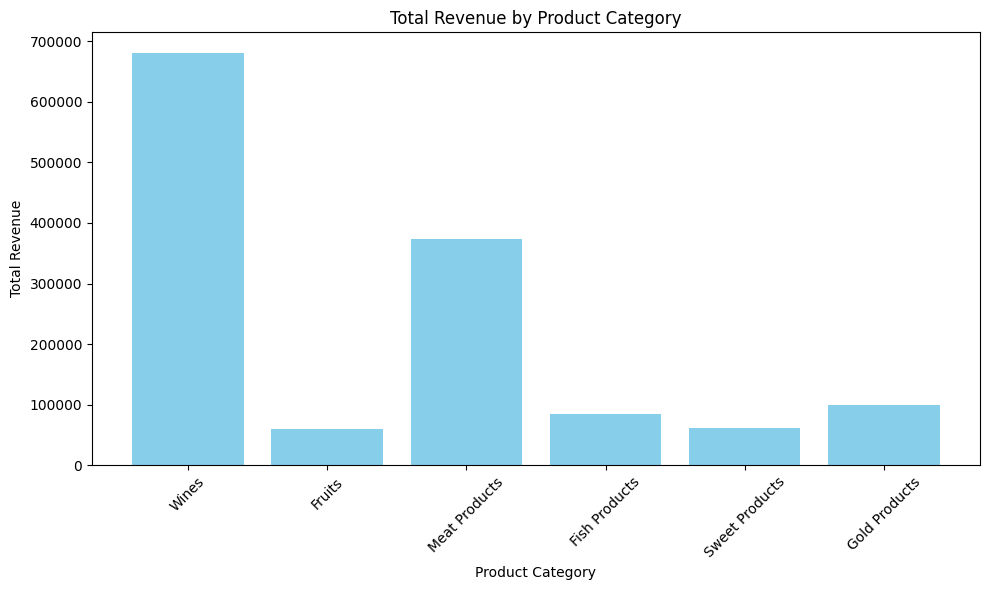

In [81]:
# Identify the top-performing products and those with the lowest revenue from the dataset.
# Calculate total revenue for each product category
df['Revenue_Wines'] = df['MntWines']
df['Revenue_Fruits'] = df['MntFruits']
df['Revenue_MeatProducts'] = df['MntMeatProducts']
df['Revenue_FishProducts'] = df['MntFishProducts']
df['Revenue_SweetProducts'] = df['MntSweetProducts']
df['Revenue_GoldProds'] = df['MntGoldProds']
# Calculate total revenue for each product category
total_revenue = {
    'Wines': df['Revenue_Wines'].sum(),
    'Fruits': df['Revenue_Fruits'].sum(),
    'Meat Products': df['Revenue_MeatProducts'].sum(),
    'Fish Products': df['Revenue_FishProducts'].sum(),
    'Sweet Products': df['Revenue_SweetProducts'].sum(),
    'Gold Products': df['Revenue_GoldProds'].sum()
}
# Sort the products by total revenue
sorted_revenue = dict(sorted(total_revenue.items(), key=lambda item: item[1], reverse=True))
print("Total Revenue by Product Category:")
for product, revenue in sorted_revenue.items():
    print(f"{product}: ${revenue:.2f}") 
# plot the total revenue for each product category
plt.figure(figsize=(10, 6))
plt.bar(total_revenue.keys(), total_revenue.values(), color='skyblue')
plt.title('Total Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [85]:
#Examine if there is a correlation between customers' age and the acceptance rate of the last campaign.
# Create a new column 'Age' based on 'Year_Birth'
current_year = 2024
df['Age'] = current_year - df['Year_Birth']
# Calculate the average age of customers who accepted the last campaign and those who did not
accepted_campaign_age = df[df['Response'] == 1]['Age'].mean()
not_accepted_campaign_age = df[df['Response'] == 0]['Age'].mean()
print(f'Average age of customers who accepted the last campaign: {accepted_campaign_age:.2f}')
print(f'Average age of customers who did not accept the last campaign: {not_accepted_campaign_age:.2f}')
# Determine the country with the highest number of customers who accepted the last campaign.
country_accepted = df[df['Response'] == 1]['Country'].value_counts().idxmax()
print(f'The country with the highest number of customers who accepted the last campaign is: {country_accepted}')

Average age of customers who accepted the last campaign: 54.58
Average age of customers who did not accept the last campaign: 55.30
The country with the highest number of customers who accepted the last campaign is: SP


Average Total Spending by Number of Children at Home:
Total_Children
0    1106.029781
1     472.733156
2     245.947743
3     274.603774
Name: Total_Spending, dtype: float64


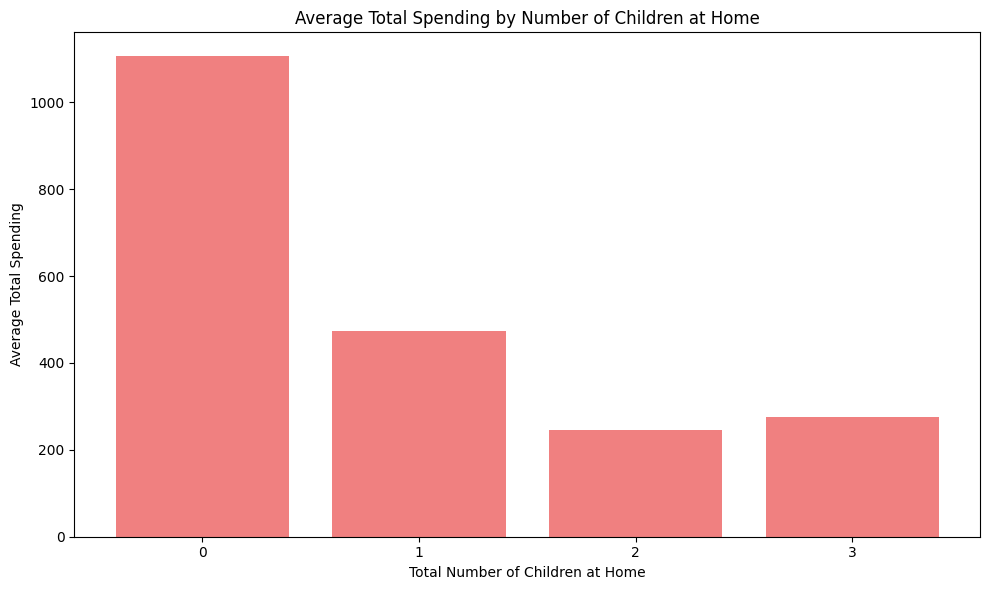

In [86]:
# - Investigate if there is a discernible pattern in the number of children at home and the total expenditure.
# Calculate the average total spending for customers with different numbers of children at home
children_spending = df.groupby('Total_Children')['Total_Spending'].mean()
print("Average Total Spending by Number of Children at Home:")
print(children_spending)
# Plot the average total spending by number of children at home
plt.figure(figsize=(10, 6))
plt.bar(children_spending.index, children_spending.values, color='lightcoral')
plt.title('Average Total Spending by Number of Children at Home')
plt.xlabel('Total Number of Children at Home')
plt.ylabel('Average Total Spending')
plt.xticks(children_spending.index)
plt.tight_layout()
plt.show()

In [87]:
# Analyze the educational background of customers who lodged complaints in the last two years.
complaint_education = df[df['Complain'] == 1]['Education'].value_counts()
print("Educational Background of Customers Who Lodged Complaints:")
print(complaint_education)

Educational Background of Customers Who Lodged Complaints:
Education
Graduation    14
2n Cycle       4
Master         2
PhD            1
Name: count, dtype: int64
